<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Practica_26_Regresion_Lasso_y_Ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Práctica**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.

In [278]:
from google.colab import drive
drive.mount('/content/mydrive/')
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn import set_config
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

Drive already mounted at /content/mydrive/; to attempt to forcibly remount, call drive.mount("/content/mydrive/", force_remount=True).


In [279]:
!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/insurance.csv

--2025-10-25 05:13:20--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55628 (54K) [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/insurance.csv.8’

insurance.csv.8     100%[===================>]  54.32K  --.-KB/s    in 0.01s   

2025-10-25 05:13:20 (4.97 MB/s) - ‘/content/drive/MyDrive/ClassFiles/insurance.csv.8’ saved [55628/55628]



In [280]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [281]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


📌 Conjunto de datos 'insurance' consta de 7 columnas, contiene informacion de derechohabientes de un seguro y cuanto le fue cobrado a cada uno por primas. El objetivo es predecir usando las 6 variables predictoras el valor de los cargos.
Las columnas son:
  * charges (númerica decimal): variable a predecir, su rango esta entre min = ~1121.87, max = ~63770.42, un promedio de ~13270.42 y una desviación estándar de ~12110.01.
  * age (númerica entera): edad del derechohabiente, cuyo rango esta entre min = 18, max = 64, un promedio de ~39 años y una desviación estándar de ~14 años.
  * bmi (númerica decimal): índice de masa corporal, cuyo rango esta entre min = 15.96 y el max = 53.13, un promedio de 30.66 y desviación estándar de 6.09.
  * children (númerica entera): cantidad de hijos, cuyo rango esta entre min = 0, max = 5, un promedio de ~1.09 hijos y una desviación estándar de ~1.20 hijos.
  * sex (categórica binaria): male, female
  * smoker(categórica binaria): yes, no

El conjunto de datos no tiene datos perdidos.
A las variables categoricas, aplicaremos onehotencoding, para codificarlas y que nuestro modelo pueda entender mejor su aportación.

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

In [283]:
# Separar columnas categóricas y númericas
def cat_num_split(df):
  cat_cols, num_cols = [], []
  for col in df.columns:
    if df[col].dtype != 'object':
      num_cols.append(col)
    else:
      cat_cols.append(col)
  return cat_cols, num_cols

cat_cols, num_cols = cat_num_split(df)

##### Gráficas para datos númericos

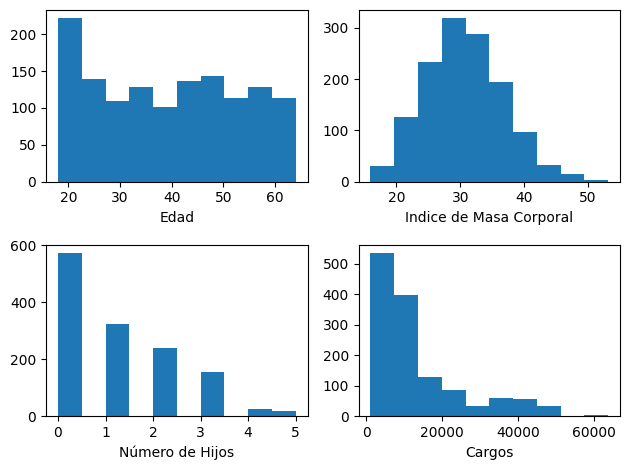

In [284]:
fig, ax = plt.subplots(2, 2)
ax[0, 0].hist(df['age'], bins=10)
ax[0, 0].set(xlabel='Edad')
ax[0, 1].hist(df['bmi'], bins=10)
ax[0, 1].set(xlabel='Indice de Masa Corporal', label='rango')
ax[1, 0].hist(df['children'], bins=10)
ax[1, 0].set(xlabel='Número de Hijos', label='rango')
ax[1, 1].hist(df['charges'], bins=10)
ax[1, 1].set(xlabel='Cargos', label='rango')
plt.tight_layout()
plt.show()

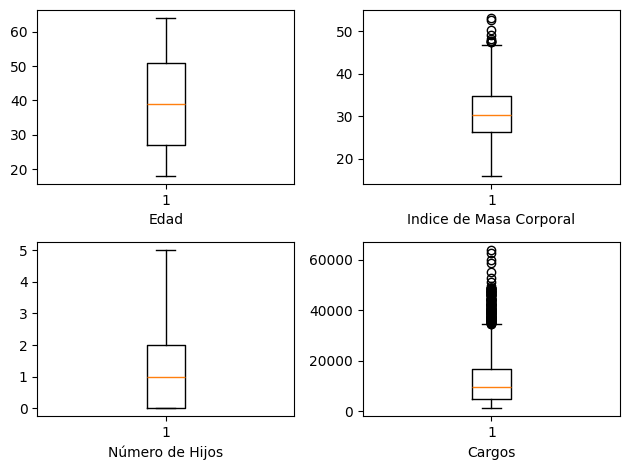

In [285]:
fig, ax = plt.subplots(2, 2)
ax[0, 0].boxplot(df['age'])
ax[0, 0].set(xlabel='Edad')
ax[0, 1].boxplot(df['bmi'])
ax[0, 1].set(xlabel='Indice de Masa Corporal')
ax[1, 0].boxplot(df['children'])
ax[1, 0].set(xlabel='Número de Hijos')
ax[1, 1].boxplot(df['charges'])
ax[1, 1].set(xlabel='Cargos')
plt.tight_layout()
plt.show()

##### Gráficas para datos categóricos

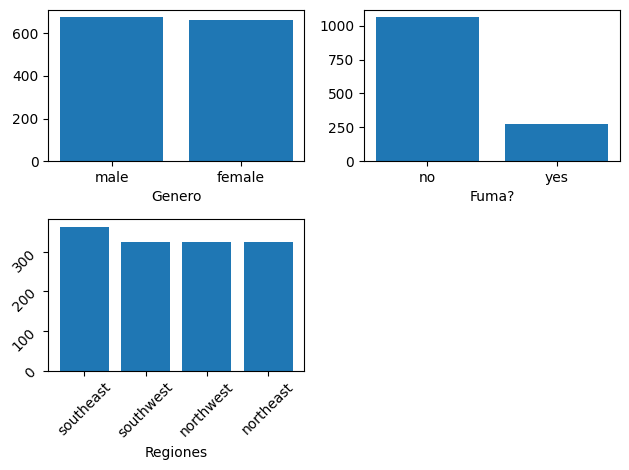

In [286]:
# ['sex', 'smoker', 'region']
fig, ax = plt.subplots(2, 2)
genre_count = df['sex'].value_counts()
ax[0, 0].bar(genre_count.index, genre_count.values)
ax[0, 0].set(xlabel='Genero')
is_smoker_count = df['smoker'].value_counts()
ax[0, 1].bar(is_smoker_count.index, is_smoker_count.values)
ax[0, 1].set(xlabel='Fuma?')
region_count = df['region'].value_counts()
ax[1, 0].bar(region_count.index, region_count.values)
ax[1, 0].set(xlabel='Regiones')
ax[1, 0].tick_params(rotation=45)
fig.delaxes(ax[1][1])
plt.tight_layout()
plt.show()

📌 Análisis de gráficas:

🔹 La distribucion de la variable edad, se asemeja a una distribución uniforme, cuyo promedio se encuentra en los ~39 años, no presenta valores atípicos, lo cuál es razonable con que las compañías de seguros no ofrezcan coberturas para mayores de 65 años.<br>
🔹La variable bmi, se parece a una distribución normal, con un sesgo hacia la izquierda, con una cola que se extiende hacia la derecha, concluyente con que existen personas que tienen un bmi mayor al promedio, se refuerza en la gráfica de boxplot, con valores atípicos.<br>
🔹El número de hijos en promedio es de 1.094 con una desviación estándar de 1.20 como es mostrado en el gráfico de caja, centrado en esta area con algunos ejemplos de un número mayor de hijos aunque sin ser valores atípicos.<br>
🔹La variable Charges, los valores atípicos representan la realidad de los costos de servicios de la salud, donde estos pueden ser más altos si existen complicaciones.<br>
🔹La variable género y Regiones estan "balanceadas" mientras que si el derechohabiente es fumador o n, donde los que constestaron sí solo son un ~1/5 de los derechohabientes.

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?<br>
**age, bmi son las variables con una correlación fuerte, mientras que children tiene una correlación baja.**

<Axes: >

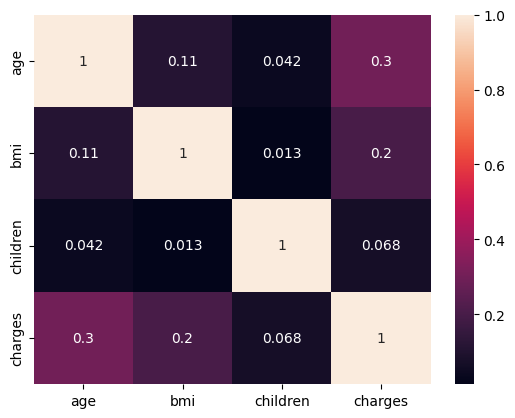

In [287]:
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True)

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

In [288]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [289]:
set_config(transform_output="pandas")

preprocessor = ColumnTransformer(
    transformers=[
      ('num', StandardScaler(), num_cols[:-1]),
      ('cat', OneHotEncoder(sparse_output=False,drop='first'), cat_cols)
    ]
)

dfp = preprocessor.fit_transform(df)
dfp

,num__age,num__bmi,num__children,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,-1.438764,-0.453320,-0.908614,0.0,1.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.078767,1.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,1.580926,1.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,-0.908614,1.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.908614,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,1.0,0.0,1.0,0.0,0.0
1334,-1.509965,0.206139,-0.908614,0.0,0.0,0.0,0.0,0.0
1335,-1.509965,1.014878,-0.908614,0.0,0.0,0.0,1.0,0.0
1336,-1.296362,-0.797813,-0.908614,0.0,0.0,0.0,0.0,1.0


In [290]:
# No tenemos valores faltantes
dfp.isna().sum()

,0
num__age,0
num__bmi,0
num__children,0
cat__sex_male,0
cat__smoker_yes,0
cat__region_northwest,0
cat__region_southeast,0
cat__region_southwest,0


#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

In [291]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [292]:
features = list(df.columns[:-1])
target = 'charges'

X = df[features]
y = df[target]

cat_cols, num_cols = cat_num_split(X)

Lasso Regression

In [293]:
set_config(transform_output="default")

alpha = 0.1
preprocessor = ColumnTransformer(
    transformers=[
      ('num', StandardScaler(), num_cols),
      ('cat', OneHotEncoder(sparse_output=True, drop='first'), cat_cols)
    ])

In [294]:
lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(alpha=alpha))
])

lasso.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('lasso', Lasso(alpha=0.1))])

age                  3607.401538
bmi                  2067.477362
children              572.886518
sex_male             -130.858174
smoker_yes          23847.874359
region_northwest     -351.296712
region_southeast    -1033.232029
region_southwest     -958.345589
dtype: float64


MSE: 36501893.680594906
RMSE: 6041.679706885736
R2 Score: 0.7509130300047799
Número de coeficientes no nulos: 8


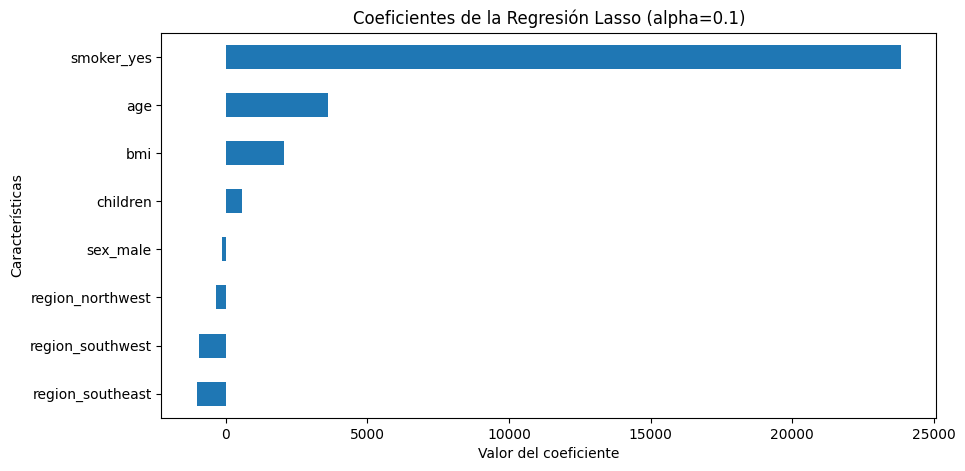

In [295]:
feature_names = num_cols + list(lasso.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out())
coef = pd.Series(lasso.named_steps["lasso"].coef_, index=feature_names)
n_nonzero_coef = np.sum(coef != 0)  # Número de coeficientes distintos de cero
print(coef)
print("\n")
y_pred_lasso = lasso.predict(X)
print(f"MSE: {mean_squared_error(y, y_pred_lasso)}")
print(f"RMSE: {root_mean_squared_error(y, y_pred_lasso)}")
print(f"R2 Score: {r2_score(y, y_pred_lasso)}")
print(f"Número de coeficientes no nulos: {n_nonzero_coef}")

# Graficar los coeficientes de la regresión Lasso
plt.figure(figsize=(10, 5))
coef.sort_values().plot(kind="barh")
plt.title(f"Coeficientes de la Regresión Lasso (alpha={alpha})")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Características")
plt.show()

In [296]:
set_config(transform_output=None)

preprocessor = ColumnTransformer(
    transformers=[
      ('num', StandardScaler(), num_cols),
      ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
    ])

In [297]:
alpha = 1.0
ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=alpha))
])

ridge.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('ridge', Ridge())])

age                  3604.096982
bmi                  2064.858647
children              573.073125
sex_male             -124.200613
smoker_yes          23737.991359
region_northwest     -347.825073
region_southeast    -1018.540799
region_southwest     -952.384021
dtype: float64


MSE: 36503887.631331325
RMSE: 6041.844720888756
R2 Score: 0.7508994233916109
Número de coeficientes no nulos: 8


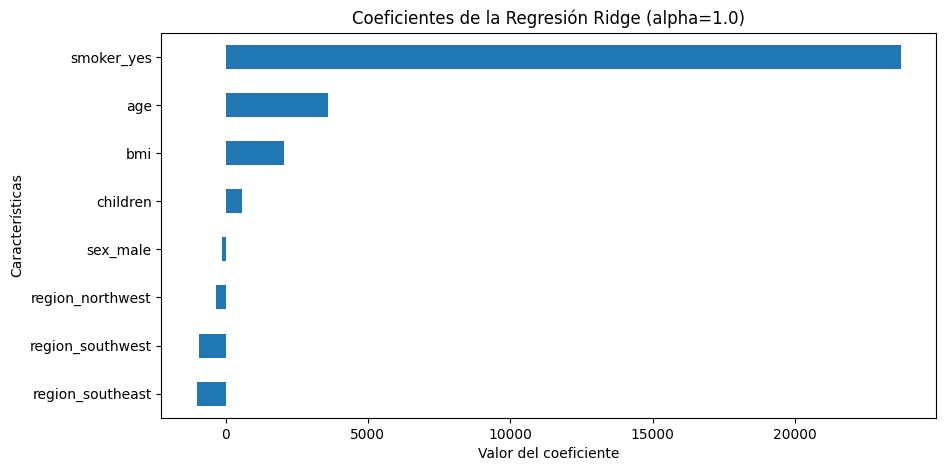

In [298]:
feature_names = num_cols + list(ridge.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out())
coef = pd.Series(ridge.named_steps["ridge"].coef_, index=feature_names)
n_nonzero_coef = np.sum(coef != 0)  # Número de coeficientes distintos de cero
print(coef)
print("\n")
y_pred_ridge = ridge.predict(X)
print(f"MSE: {mean_squared_error(y, y_pred_ridge)}")
print(f"RMSE: {root_mean_squared_error(y, y_pred_ridge)}")
print(f"R2 Score: {r2_score(y, y_pred_ridge)}")
print(f"Número de coeficientes no nulos: {n_nonzero_coef}")

# Graficar los coeficientes de la regresión Ridge
plt.figure(figsize=(10, 5))
coef.sort_values().plot(kind="barh")
plt.title(f"Coeficientes de la Regresión Ridge (alpha={alpha})")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Características")
plt.show()

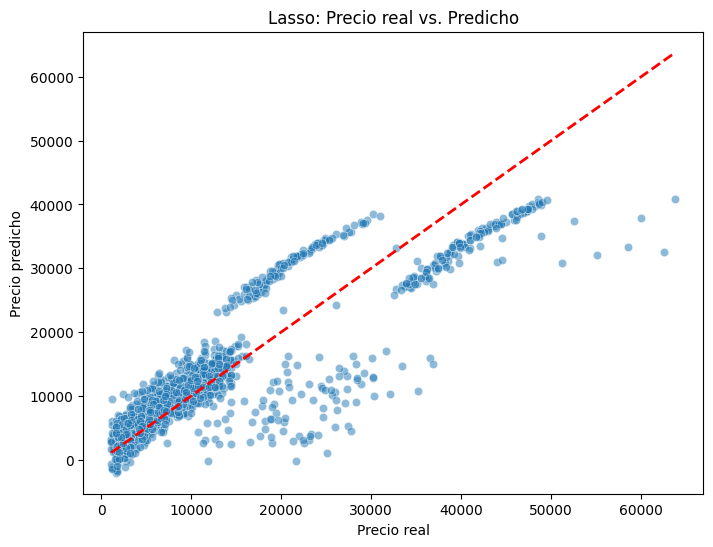

In [299]:
# Gráfico de dispersión: Precio real vs. Predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_lasso, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Lasso: Precio real vs. Predicho")
plt.show()

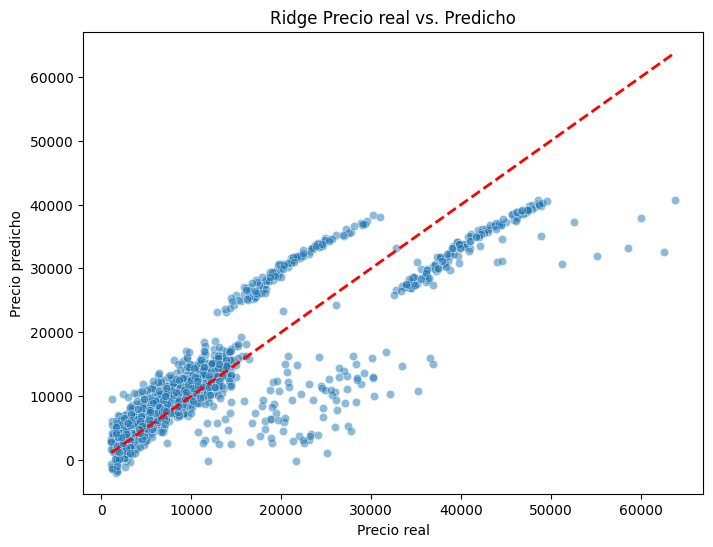

In [300]:
# Gráfico de dispersión: Precio real vs. Predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_ridge, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Ridge Precio real vs. Predicho")
plt.show()

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

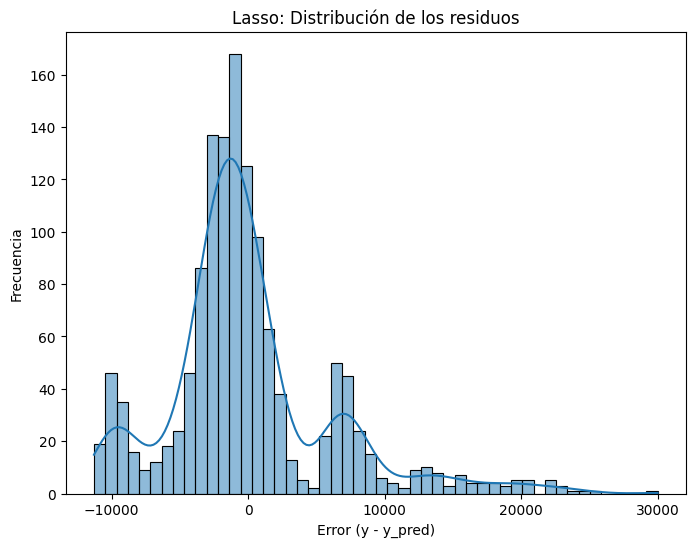

In [301]:
# Histograma de residuos
residuals_lasso = y - y_pred_lasso
plt.figure(figsize=(8, 6))
sns.histplot(residuals_lasso, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Lasso: Distribución de los residuos")
plt.show()

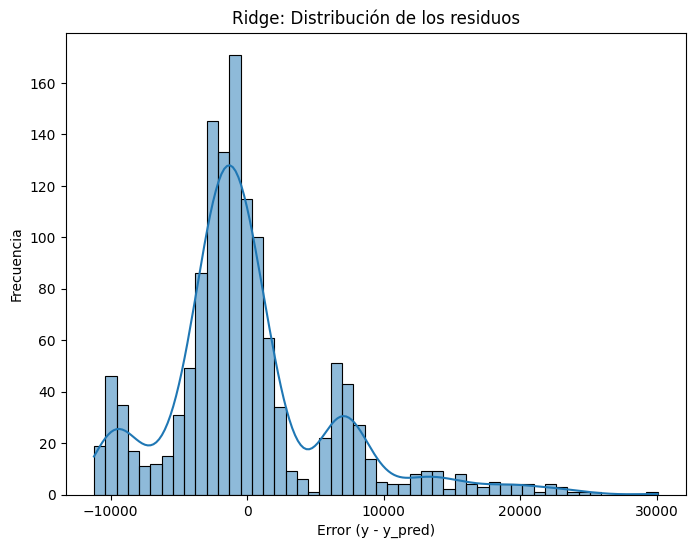

In [302]:
# Histograma de residuos
residuals_ridge = y - y_pred_ridge
plt.figure(figsize=(8, 6))
sns.histplot(residuals_ridge, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Ridge: Distribución de los residuos")
plt.show()

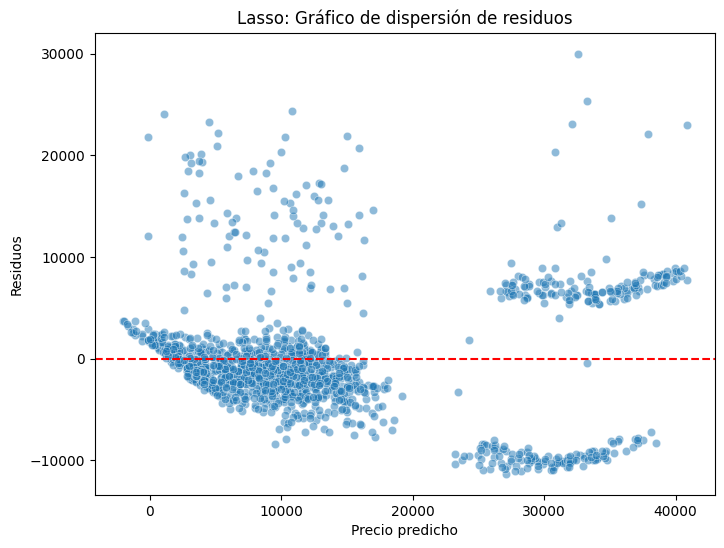

In [303]:
# Gráfico de dispersión de residuos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Lasso: Gráfico de dispersión de residuos")
plt.show()

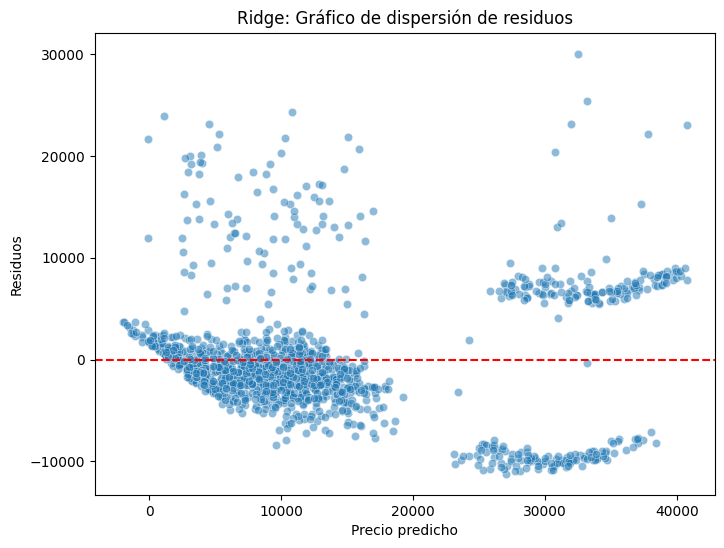

In [304]:
# Gráfico de dispersión de residuos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Ridge: Gráfico de dispersión de residuos")
plt.show()

Test Statistic: 0.8989319623266138, p-value: 8.355430728213068e-29
Residuale|s Lasso no parece normalmente distribuido


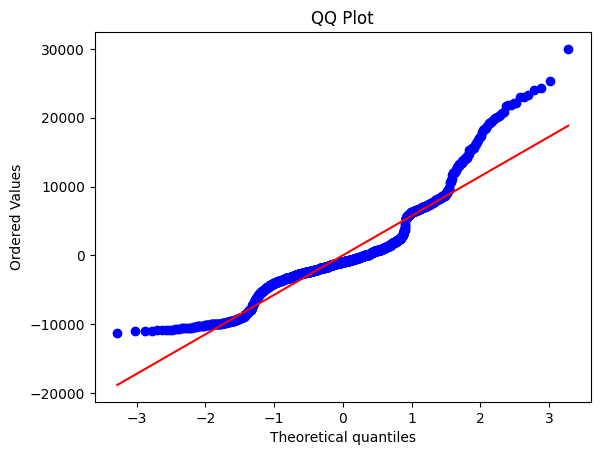

Test Statistic: 0.8979982412623401, p-value: 6.458843138896771e-29
Residuales Lasso no parece normalmente distribuido


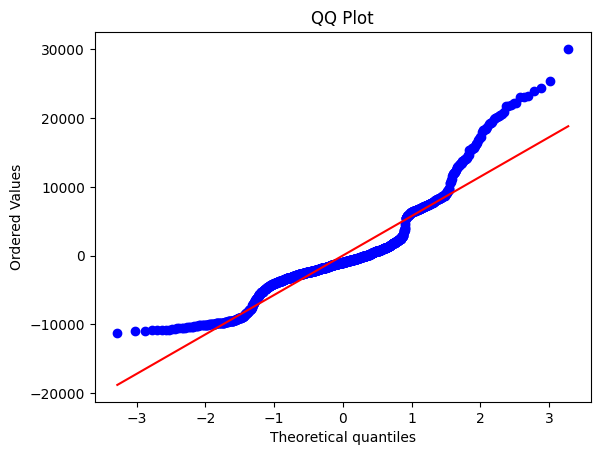

In [305]:
# 2.
stat, p = shapiro(residuals_lasso)
print(f"Test Statistic: {stat}, p-value: {p}")

if p > 0.05:
    print("Residuales Lasso parece normalmente distribuido.")
else:
    print("Residuale|s Lasso no parece normalmente distribuido")

stats.probplot(residuals_lasso, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

stat, p = shapiro(residuals_ridge)
print(f"Test Statistic: {stat}, p-value: {p}")

if p > 0.05:
    print("Residuales Lasso parece normalmente distribuido.")
else:
    print("Residuales Lasso no parece normalmente distribuido")

stats.probplot(residuals_ridge, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

In [306]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [307]:
X_sm = sm.add_constant(dfp)
bp_test = het_breuschpagan(residuals_lasso, X_sm)

# Extract test results
bp_stat = bp_test[0]  # Breusch-Pagan statistic
bp_pvalue = bp_test[1]  # p-value
print(f"Lasso Breusch-Pagan Statistic: {bp_stat}")
print(f"P-value: {bp_pvalue}")

# Interpretation
if bp_pvalue < 0.05:
    print("heterocedasticidad detectada (reject null hypothesis).")
else:
    print("heterocedasticidad no detectada  (fail to reject null hypothesis).")

Lasso Breusch-Pagan Statistic: 121.74938669263518
P-value: 1.4427409697798183e-22
heterocedasticidad detectada (reject null hypothesis).


In [308]:
X_sm = sm.add_constant(dfp)
bp_test = het_breuschpagan(residuals_ridge, X_sm)

# Extract test results
bp_stat = bp_test[0]  # Breusch-Pagan statistic
bp_pvalue = bp_test[1]  # p-value
print(f"Ridge Breusch-Pagan Statistic: {bp_stat}")
print(f"P-value: {bp_pvalue}")

# Interpretation
if bp_pvalue < 0.05:
    print("heterocedasticidad detectada (reject null hypothesis).")
else:
    print("heterocedasticidad no detectada  (fail to reject null hypothesis).")

Ridge Breusch-Pagan Statistic: 122.22395575936338
P-value: 1.1511217628166822e-22
heterocedasticidad detectada (reject null hypothesis).


In [309]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = dfp.assign(const=1)  # Agregar constante para el modelo
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                Variable       VIF
0               num__age  1.016822
1               num__bmi  1.106630
2          num__children  1.004011
3          cat__sex_male  1.008900
4        cat__smoker_yes  1.012074
5  cat__region_northwest  1.518823
6  cat__region_southeast  1.652230
7  cat__region_southwest  1.529411
8                  const  5.428992




📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos? <br>
  ** Se encontró heterocedasticidad en los residuales de ambos modelos**
- Si hay heterocedasticidad, ¿cómo podría solucionarse? <br>
  **aplicar transformaciones distintas, utilizar otros metodos de optimizacion, evaluar la contribucion individual de cada modelo a la prediccion final.**


#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

**Ambos modelos entregaron resultados similares. No sucedió eliminacion de coeficientes para Lasso o reduccion de coeficientes para Ridge**
---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  